In [3]:
"""
=============================================================================
GROUP 08 — Multiclass Text Classification Pipeline
=============================================================================
TASK   : Predict label (0/1/2/3) from free-text posts
METRIC : Macro F1 Score
MODELS : 9 ML models + 3 Deep Learning models (TF/Keras)
OUTPUT : 3 Excel files — top ML #1, top ML #2, top DL #1

INSTALL:
    pip install scikit-learn xgboost lightgbm tensorflow openpyxl pandas numpy scipy

USAGE:
    python complete_pipeline_v2.py
=============================================================================
"""

# ── Imports ──────────────────────────────────────────────────────────────────
import os, re, warnings, pickle
import numpy as np
import pandas as pd
from scipy.sparse import hstack

os.environ['TF_CPP_MIN_LOG_LEVEL']   = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS']  = '0'
os.environ['CUDA_VISIBLE_DEVICES']   = ''          # CPU only — remove to use GPU
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import xgboost as xgb
import lightgbm as lgb
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, Input, Embedding, Conv1D, GlobalMaxPooling1D,
    LSTM, Bidirectional, SpatialDropout1D, BatchNormalization
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers

# ═══════════════════════════════════════════════════════════════════════════
# 0.  FILE PATHS
# ═══════════════════════════════════════════════════════════════════════════
TRAIN_PATH = "/content/Multilabel_Train.csv"
VAL_PATH   = "/content/Multilabel_Val.csv"
TEST_PATH  = "/content/Multilabel_Test - Competition.csv"
OUTPUT_DIR = "."

# ═══════════════════════════════════════════════════════════════════════════
# 1.  LOAD DATA
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  STEP 1 — Loading Data")
print("="*65)

train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)

print(f"  Train: {train.shape[0]:,}  Val: {val.shape[0]:,}  Test: {test.shape[0]:,}")
print(f"  Label distribution (train):\n{train['label'].value_counts().sort_index()}")

# ═══════════════════════════════════════════════════════════════════════════
# 2.  PREPROCESSING
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  STEP 2 — Preprocessing")
print("="*65)

def preprocess(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\d+', ' NUM ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

for df in (train, val, test):
    df['clean'] = df['text'].apply(preprocess)
print("  Done.")

y_tr = train['label'].values
y_v  = val['label'].values

# ═══════════════════════════════════════════════════════════════════════════
# 3.  FEATURES
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  STEP 3 — Feature Engineering (TF-IDF)")
print("="*65)

tfidf_word = TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True, min_df=2)
tfidf_char = TfidfVectorizer(max_features=15000, analyzer='char_wb', ngram_range=(3,5), sublinear_tf=True, min_df=3)
tfidf_word.fit(train['clean']); tfidf_char.fit(train['clean'])

Xw_tr = tfidf_word.transform(train['clean']); Xw_v = tfidf_word.transform(val['clean']); Xw_te = tfidf_word.transform(test['clean'])
Xc_tr = tfidf_char.transform(train['clean']); Xc_v = tfidf_char.transform(val['clean']); Xc_te = tfidf_char.transform(test['clean'])
X_tr  = hstack([Xw_tr, Xc_tr]); X_v = hstack([Xw_v, Xc_v]); X_te = hstack([Xw_te, Xc_te])

print(f"  Combined TF-IDF: {X_tr.shape}")

# ═══════════════════════════════════════════════════════════════════════════
# 4.  ML MODELS
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  STEP 4 — Machine Learning Models")
print("="*65)

ml_results    = {}
ml_val_preds  = {}
ml_test_preds = {}

def run_ml(name, model, Xtr, Xv, Xte, y_tr, y_v):
    print(f"\n  ── {name}")
    model.fit(Xtr, y_tr)
    vp = model.predict(Xv); tp = model.predict(Xte)
    f1 = f1_score(y_v, vp, average='macro')
    ml_results[name]    = f1
    ml_val_preds[name]  = vp
    ml_test_preds[name] = tp
    print(f"  Macro F1 = {f1:.4f}")
    print(classification_report(y_v, vp, digits=4))
    cm = confusion_matrix(y_v, vp)
    print("  Confusion Matrix:")
    print(pd.DataFrame(cm, index=[f"A{i}" for i in range(4)], columns=[f"P{i}" for i in range(4)]).to_string())
    return model

# 1. Logistic Regression (C=5)
lr5 = run_ml("LR (C=5)", LogisticRegression(C=5, max_iter=1000, class_weight='balanced', solver='saga'), X_tr, X_v, X_te, y_tr, y_v)
# 2. LR (C=10)
lr10 = run_ml("LR (C=10)", LogisticRegression(C=10, max_iter=1000, class_weight='balanced', solver='saga'), X_tr, X_v, X_te, y_tr, y_v)
# 3. LR (C=1)
lr1 = run_ml("LR (C=1)", LogisticRegression(C=1, max_iter=1000, class_weight='balanced', solver='saga'), X_tr, X_v, X_te, y_tr, y_v)
# 4. Linear SVM
run_ml("Linear SVM", LinearSVC(C=1.0, max_iter=2000, class_weight='balanced'), X_tr, X_v, X_te, y_tr, y_v)
# 5. Complement NB (word tfidf only)
run_ml("Complement NB", ComplementNB(alpha=0.3), Xw_tr, Xw_v, Xw_te, y_tr, y_v)
# 6. Random Forest
run_ml("Random Forest", RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42), Xw_tr, Xw_v, Xw_te, y_tr, y_v)
# 7. XGBoost
run_ml("XGBoost", xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0), Xw_tr, Xw_v, Xw_te, y_tr, y_v)
# 8. LightGBM
run_ml("LightGBM", lgb.LGBMClassifier(n_estimators=200, max_depth=7, learning_rate=0.1, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1), Xw_tr, Xw_v, Xw_te, y_tr, y_v)

# 9. Soft Ensemble: LR5 + LR10
print("\n  ── Ensemble (LR C5 + LR C10 soft vote)")
ens_vp = np.argmax((lr5.predict_proba(X_v) + lr10.predict_proba(X_v)) / 2, axis=1)
ens_tp = np.argmax((lr5.predict_proba(X_te) + lr10.predict_proba(X_te)) / 2, axis=1)
ens_f1 = f1_score(y_v, ens_vp, average='macro')
ml_results["Ensemble LR"]    = ens_f1
ml_val_preds["Ensemble LR"]  = ens_vp
ml_test_preds["Ensemble LR"] = ens_tp
print(f"  Macro F1 = {ens_f1:.4f}")

# ═══════════════════════════════════════════════════════════════════════════
# 5.  DEEP LEARNING MODELS
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  STEP 5 — Deep Learning Models")
print("="*65)

dl_results    = {}
dl_val_preds  = {}
dl_test_preds = {}

cw = compute_class_weight('balanced', classes=np.array([0,1,2,3]), y=y_tr)
cwd = {i:w for i,w in enumerate(cw)}
y_tr_oh = to_categorical(y_tr, 4)
y_v_oh  = to_categorical(y_v,  4)

cb = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0)]

def dl_eval(name, model, Xv, Xte, y_v):
    vp = np.argmax(model.predict(Xv, verbose=0), axis=1)
    tp = np.argmax(model.predict(Xte, verbose=0), axis=1)
    f1 = f1_score(y_v, vp, average='macro')
    dl_results[name]    = f1
    dl_val_preds[name]  = vp
    dl_test_preds[name] = tp
    print(f"\n  [{name}] Macro F1 = {f1:.4f}")
    print(classification_report(y_v, vp, digits=4))
    cm = confusion_matrix(y_v, vp)
    print("  Confusion Matrix:")
    print(pd.DataFrame(cm, index=[f"A{i}" for i in range(4)], columns=[f"P{i}" for i in range(4)]).to_string())

# ── DL1: Deep MLP on TF-IDF (5000 features to keep RAM manageable) ─────────
print("\n  ── DL1: Deep MLP on TF-IDF")
tfidf_dense = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True, min_df=2)
tfidf_dense.fit(train['clean'])
Xd_tr = tfidf_dense.transform(train['clean']).toarray().astype('float32')
Xd_v  = tfidf_dense.transform(val['clean']).toarray().astype('float32')
Xd_te = tfidf_dense.transform(test['clean']).toarray().astype('float32')

inp = Input(shape=(5000,))
x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(inp)
x = BatchNormalization()(x); x = Dropout(0.4)(x)
x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = BatchNormalization()(x); x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x); x = Dropout(0.3)(x)
out = Dense(4, activation='softmax')(x)
mlp_model = Model(inp, out)
mlp_model.compile(optimizer=Adam(3e-4), loss='categorical_crossentropy', metrics=['accuracy'])
mlp_model.summary()
mlp_model.fit(Xd_tr, y_tr_oh, validation_data=(Xd_v, y_v_oh), epochs=60, batch_size=64, class_weight=cwd, callbacks=cb, verbose=1)
dl_eval("Deep MLP (512-256-128)", mlp_model, Xd_v, Xd_te, y_v)

# ── DL2: 1D CNN with learnable embeddings ────────────────────────────────────
print("\n  ── DL2: 1D CNN with Embeddings")
VOCAB=15000; MAXLEN=150; EDIM=64
tok = Tokenizer(num_words=VOCAB, oov_token='<OOV>'); tok.fit_on_texts(train['clean'])
def seqs(texts): return pad_sequences(tok.texts_to_sequences(texts), maxlen=MAXLEN, padding='post', truncating='post')
Xs_tr=seqs(train['clean']); Xs_v=seqs(val['clean']); Xs_te=seqs(test['clean'])

inp2 = Input(shape=(MAXLEN,))
x2 = Embedding(VOCAB, EDIM, input_length=MAXLEN)(inp2)
x2 = SpatialDropout1D(0.3)(x2)
x2 = Conv1D(128, 5, activation='relu', padding='same')(x2)
x2 = Conv1D(128, 3, activation='relu', padding='same')(x2)
x2 = GlobalMaxPooling1D()(x2)
x2 = Dense(128, activation='relu')(x2); x2 = Dropout(0.4)(x2)
x2 = Dense(64, activation='relu')(x2);  x2 = Dropout(0.3)(x2)
out2 = Dense(4, activation='softmax')(x2)
cnn_model = Model(inp2, out2)
cnn_model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()
cnn_model.fit(Xs_tr, y_tr_oh, validation_data=(Xs_v, y_v_oh), epochs=30, batch_size=64, class_weight=cwd, callbacks=cb, verbose=1)
dl_eval("1D CNN (Embeddings)", cnn_model, Xs_v, Xs_te, y_v)

# ── DL3: Bidirectional LSTM ──────────────────────────────────────────────────
print("\n  ── DL3: Bidirectional LSTM")
inp3 = Input(shape=(MAXLEN,))
x3 = Embedding(VOCAB, EDIM, input_length=MAXLEN)(inp3)
x3 = SpatialDropout1D(0.3)(x3)
x3 = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(x3)
x3 = Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2))(x3)
x3 = Dense(64, activation='relu')(x3); x3 = Dropout(0.3)(x3)
out3 = Dense(4, activation='softmax')(x3)
lstm_model = Model(inp3, out3)
lstm_model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()
lstm_model.fit(Xs_tr, y_tr_oh, validation_data=(Xs_v, y_v_oh), epochs=20, batch_size=64, class_weight=cwd, callbacks=cb, verbose=1)
dl_eval("Bidirectional LSTM", lstm_model, Xs_v, Xs_te, y_v)

# ═══════════════════════════════════════════════════════════════════════════
# 6.  RANKING SUMMARIES
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  STEP 6 — Rankings")
print("="*65)

ml_sorted = sorted(ml_results.items(), key=lambda x: x[1], reverse=True)
dl_sorted = sorted(dl_results.items(), key=lambda x: x[1], reverse=True)

print(f"\n  {'Rank':<5} {'ML Model':<38} {'Macro F1':>10}")
print("  " + "-"*55)
for rank, (name, f1) in enumerate(ml_sorted, 1):
    marker = " ◄ TOP 3" if rank <= 3 else ""
    print(f"  {rank:<5} {name:<38} {f1:>10.4f}{marker}")

print(f"\n  {'Rank':<5} {'DL Model':<45} {'Macro F1':>10}")
print("  " + "-"*60)
for rank, (name, f1) in enumerate(dl_sorted, 1):
    marker = " ◄ TOP 3" if rank <= 3 else ""
    print(f"  {rank:<5} {name:<45} {f1:>10.4f}{marker}")

# ═══════════════════════════════════════════════════════════════════════════
# 7.  GENERATE 3 TEST PREDICTION FILES
#     Attempt 1 = Best ML
#     Attempt 2 = 2nd Best ML
#     Attempt 3 = Best DL
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  STEP 7 — Writing Test Prediction Files")
print("="*65)

def save_excel(filepath, dataframe, model_name, macro_f1):
    wb = openpyxl.Workbook()
    ws = wb.active; ws.title = "Predictions"
    hfill = PatternFill("solid", fgColor="1F4E79")
    hfont = Font(bold=True, color="FFFFFF", name="Arial", size=11)
    for ci, col in enumerate(dataframe.columns, 1):
        c = ws.cell(row=1, column=ci, value=col)
        c.fill=hfill; c.font=hfont; c.alignment=Alignment(horizontal="center")
    lci = list(dataframe.columns).index("label") + 1
    lfill = PatternFill("solid", fgColor="E2EFDA")
    for ri, row in enumerate(dataframe.itertuples(index=False), 2):
        for ci, v in enumerate(row, 1):
            c = ws.cell(row=ri, column=ci, value=v)
            c.font = Font(name="Arial", size=10)
            if ci == lci:
                c.fill=lfill; c.font=Font(name="Arial", size=10, bold=True); c.alignment=Alignment(horizontal="center")
    ws.column_dimensions["A"].width=12; ws.column_dimensions["B"].width=90; ws.column_dimensions["C"].width=10
    ws2 = wb.create_sheet("Model Info")
    ws2.column_dimensions["A"].width=25; ws2.column_dimensions["B"].width=50
    meta = [("Group","Group #08"),("Model",model_name),("Macro F1 (val)",f"{macro_f1:.4f}"),("Metric","Macro F1")]
    for r,(k,v) in enumerate(meta,1):
        ws2.cell(r,1,k).font=Font(bold=True,name="Arial"); ws2.cell(r,2,v).font=Font(name="Arial")
    wb.save(filepath)
    print(f"  ✓ {filepath}")

attempts = [
    (ml_sorted[0][0], ml_results[ml_sorted[0][0]], ml_test_preds[ml_sorted[0][0]]),
    (ml_sorted[1][0], ml_results[ml_sorted[1][0]], ml_test_preds[ml_sorted[1][0]]),
    (dl_sorted[0][0], dl_results[dl_sorted[0][0]], dl_test_preds[dl_sorted[0][0]]),
]

import os
for attempt, (model_name, f1, test_pred) in enumerate(attempts, 1):
    tc = test.copy(); tc["label"] = test_pred.astype(int)
    fname = os.path.join(OUTPUT_DIR, f"Group # 08__Multilabel_Test - Competition__Attempt {attempt}.xlsx")
    save_excel(fname, tc, model_name, f1)

print("\n" + "="*65)
print("  ALL DONE")
print("="*65)
print(f"\n  Attempt 1: {attempts[0][0]}  (ML #1, F1={attempts[0][1]:.4f})")
print(f"  Attempt 2: {attempts[1][0]}  (ML #2, F1={attempts[1][1]:.4f})")
print(f"  Attempt 3: {attempts[2][0]}  (DL #1, F1={attempts[2][1]:.4f})")


  STEP 1 — Loading Data
  Train: 2,131  Val: 711  Test: 711
  Label distribution (train):
label
0    1551
1     174
2     236
3     170
Name: count, dtype: int64

  STEP 2 — Preprocessing
  Done.

  STEP 3 — Feature Engineering (TF-IDF)
  Combined TF-IDF: (2131, 35000)

  STEP 4 — Machine Learning Models

  ── LR (C=5)
  Macro F1 = 0.4513
              precision    recall  f1-score   support

           0     0.8327    0.8649    0.8485       518
           1     0.3243    0.2069    0.2526        58
           2     0.3625    0.3671    0.3648        79
           3     0.3393    0.3393    0.3393        56

    accuracy                         0.7145       711
   macro avg     0.4647    0.4445    0.4513       711
weighted avg     0.7001    0.7145    0.7060       711

  Confusion Matrix:
     P0  P1  P2  P3
A0  448  14  35  21
A1   29  12  10   7
A2   33   8  29   9
A3   28   3   6  19

  ── LR (C=10)
  Macro F1 = 0.4449
              precision    recall  f1-score   support

           0

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,560,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,728,324 (10.41 MB)

 Trainable params: 2,726,788 (10.40 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 150, 64)        │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 150, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 150, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,071,684 (4.09 MB)

 Trainable params: 1,071,684 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 44s 854ms/step - accuracy: 0.3144 - loss: 1.3880 - val_accuracy: 0.0858 - val_loss: 1.3826 - learning_rate: 0.0010
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 771ms/step - accuracy: 0.3487 - loss: 1.3820 - val_accuracy: 0.5654 - val_loss: 1.2485 - learning_rate: 0.0010
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 769ms/step - accuracy: 0.5504 - loss: 1.3093 - val_accuracy: 0.5682 - val_loss: 1.0694 - learning_rate: 5.0000e-04
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 758ms/step - accuracy: 0.5922 - loss: 1.2178 - val_accuracy: 0.4529 - val_loss: 1.2631 - learning_rate: 5.0000e-04
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 42s 817ms/step - accuracy: 0.6363 - loss: 1.1556 - val_accuracy: 0.5345 - val_loss: 1.1140 - learning_rate: 2.5000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.

  [Bidirectional LSTM] Macro F1 = 0.0407
              precision    recall  f1-score   support

           0     1.0000    0.0058    0.0115

### 8. Confusion Matrix Visualization
This section generates heatmaps for all models to visualize classification performance across all four labels.

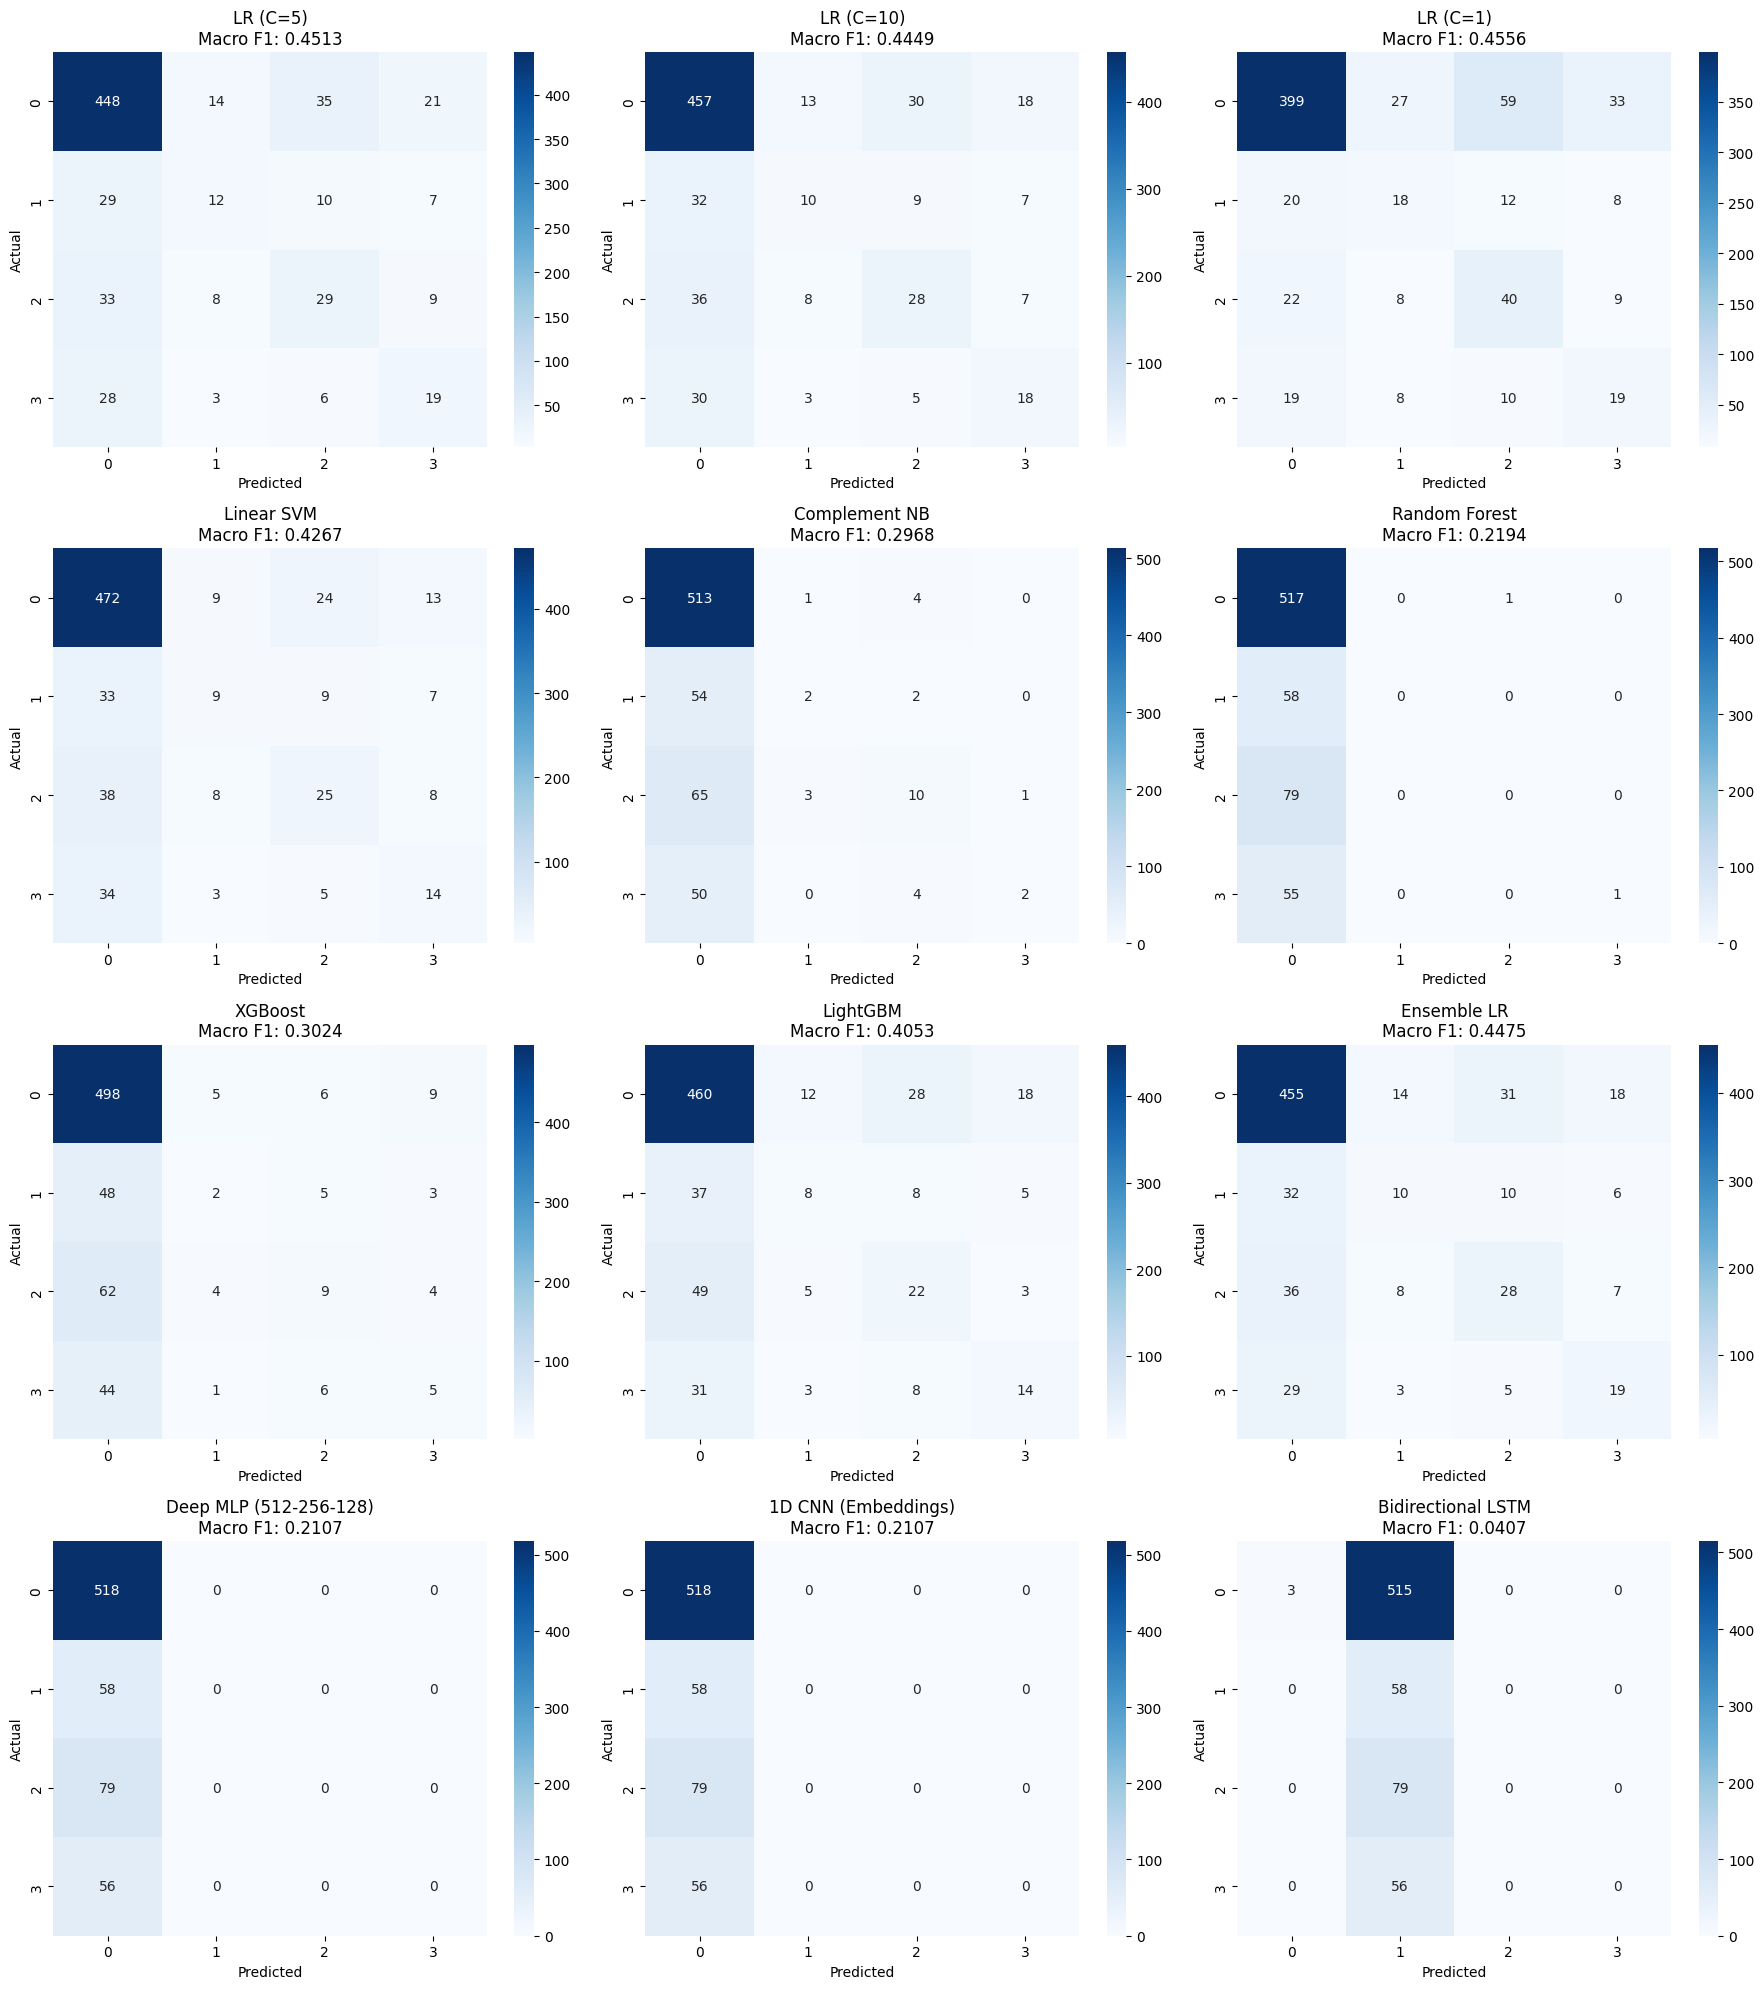

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_all_cms(ml_results, ml_val_preds, dl_results, dl_val_preds, y_true):
    all_models = {**ml_val_preds, **dl_val_preds}
    n_models = len(all_models)
    cols = 3
    rows = (n_models + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    axes = axes.flatten()

    for i, (name, preds) in enumerate(all_models.items()):
        cm = confusion_matrix(y_true, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
        axes[i].set_title(f"{name}\nMacro F1: {f1_score(y_true, preds, average='macro'):.4f}")
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

plot_all_cms(ml_results, ml_val_preds, dl_results, dl_val_preds, y_v)